# Retrieval Dataset Analysis

Notebook for dataset-level inspection using the refactored `src/` package. It is also the canonical source for the report's dataset statistics and embedding-inspection evidence.

In [1]:
import sys
from pathlib import Path

def detect_runtime_environment() -> str:
    try:
        import google.colab  # type: ignore  # noqa: F401
        return 'colab'
    except Exception:
        if Path('/kaggle/input').exists():
            return 'kaggle'
        return 'local'

def add_project_root_to_syspath(project_name: str = 'retrieval_project') -> None:
    runtime_env = detect_runtime_environment()
    candidates = [Path.cwd(), *Path.cwd().parents]
    if runtime_env == 'colab':
        drive_root = Path('/content/drive/MyDrive')
        if not drive_root.exists():
            from google.colab import drive  # type: ignore
            drive.mount('/content/drive', force_remount=False)
        candidates = [Path('/content'), Path('/content/drive/MyDrive'), Path('/content/drive/Shareddrives'), *candidates]
    elif runtime_env == 'kaggle':
        candidates = [Path('/kaggle/working'), *candidates]

    seen = set()
    for base in candidates:
        key = str(base)
        if key in seen:
            continue
        seen.add(key)
        if (base / 'src' / 'infra' / 'notebook.py').exists():
            sys.path.insert(0, str(base))
            return
        if (base / project_name / 'src' / 'infra' / 'notebook.py').exists():
            sys.path.insert(0, str(base / project_name))
            return
        if runtime_env == 'colab' and base.exists():
            for match in base.rglob(project_name):
                if (match / 'src' / 'infra' / 'notebook.py').exists():
                    sys.path.insert(0, str(match))
                    return
    raise FileNotFoundError('Could not locate project root containing src/infra/notebook.py')

add_project_root_to_syspath()

from src.infra.notebook import setup_notebook

runtime_env, project_root = setup_notebook()
print(f'Detected runtime: {runtime_env}')
print(f'Project root    : {project_root}')


Detected runtime: local
Project root    : /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project


## Step 1: Load Data

In [2]:
import json

import numpy as np
import pandas as pd

from src.config import DEFAULT_CONFIG
from src.data.text import tokenize
from src.evaluation import load_ground_truth
from src.pipeline import bootstrap, load_project_frames

paths, config = bootstrap()
frames = load_project_frames(paths, DEFAULT_CONFIG)
ground_truth = load_ground_truth(paths.data_dir / 'qgts_train.json')
with open(paths.data_dir / 'qgts_train.json', 'r', encoding='utf-8') as handle:
    raw_ground_truth = json.load(handle)

print(f'Documents     : {len(frames.docs):,}')
print(f'Train queries : {len(frames.train_queries):,}')
print(f'Test queries  : {len(frames.test_queries):,}')
print(f'Ground truth  : {len(ground_truth):,}')


Documents     : 216,041
Train queries : 327
Test queries  : 141
Ground truth  : 327


## Step 2: Dataset Fields and Counts

In [3]:
sample_qrel = next(iter(raw_ground_truth.values()))
nested_relevant_fields = []
if sample_qrel.get('relevant_doc_ids'):
    nested_relevant_fields = sorted(sample_qrel['relevant_doc_ids'][0].keys())

dataset_fields_df = pd.DataFrame(
    {
        'Dataset': ['documents', 'train_queries', 'test_queries', 'qrels'],
        'Fields': [
            ', '.join(sorted(frames.docs_raw.columns.tolist())),
            ', '.join(sorted(frames.train_queries_raw.columns.tolist())),
            ', '.join(sorted(frames.test_queries_raw.columns.tolist())),
            ', '.join(sorted(sample_qrel.keys())),
        ],
        'Nested relevant_doc_ids fields': [
            '-',
            '-',
            '-',
            ', '.join(nested_relevant_fields) if nested_relevant_fields else '-',
        ],
    }
)
total_relevance_judgments = sum(len(info['relevant_doc_ids']) for info in ground_truth.values())
avg_relevant_per_query = total_relevance_judgments / max(len(ground_truth), 1)

print(f'Total relevance judgments: {total_relevance_judgments:,}')
print(f'Average relevant docs/query: {avg_relevant_per_query:.2f}')
dataset_fields_df


Total relevance judgments: 2,970
Average relevant docs/query: 9.08


,Dataset,Fields,Nested relevant_doc_ids fields
0,documents,"category, id, tags, text, title",-
1,train_queries,"category, id, tags, text, title",-
2,test_queries,"id, tags, text, title",-
3,qrels,"category, relevant_doc_ids, total_relevant_docs","doc_id, relevance"


## Step 3: Category Distribution

Saved category figure to: /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project/reports/figures/dataset-distribution.png


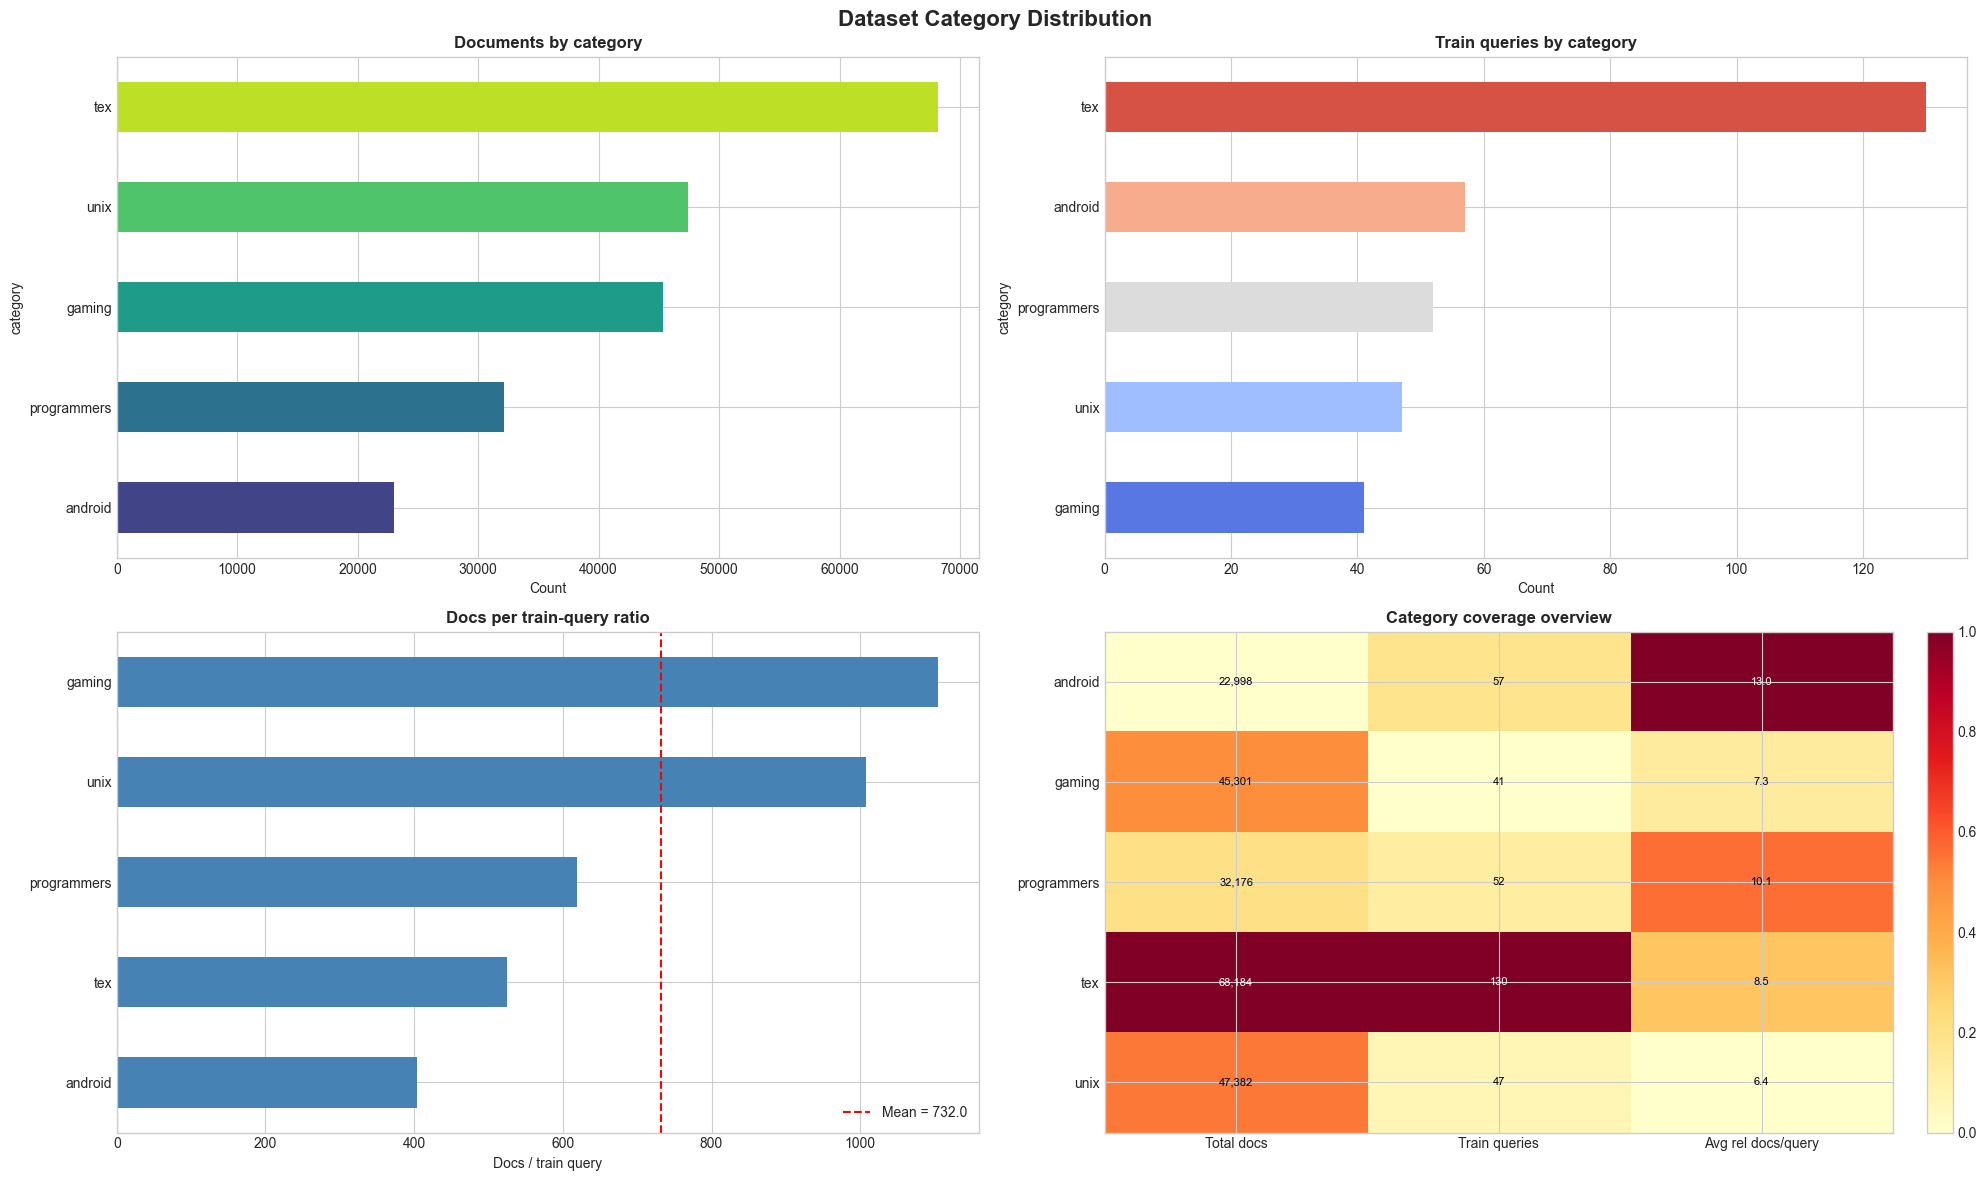

,documents,train_queries,test_queries,avg_rel_docs_per_train_query,docs_per_train_query
tex,68184,130,0,8.484615,524.492308
unix,47382,47,0,6.382979,1008.127660
gaming,45301,41,0,7.268293,1104.902439
programmers,32176,52,0,10.115385,618.769231
android,22998,57,0,13.035088,403.473684


In [4]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

figures_dir = paths.project_dir / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

doc_counts = frames.docs['category'].value_counts().sort_values(ascending=True)
train_counts = frames.train_queries['category'].value_counts().sort_values(ascending=True)
test_counts = frames.test_queries['category'].value_counts().sort_values(ascending=True) if 'category' in frames.test_queries.columns else pd.Series(dtype=int)

gt_by_cat = {}
for entry in ground_truth.values():
    cat = entry['category']
    gt_by_cat.setdefault(cat, []).append(len(entry['relevant_doc_ids']))

all_categories = sorted(set(doc_counts.index) | set(train_counts.index) | set(test_counts.index))
ratio_series = pd.Series({cat: doc_counts.get(cat, 0) / max(train_counts.get(cat, 0), 1) for cat in all_categories}).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Dataset Category Distribution', fontsize=16, fontweight='bold')

doc_colors = plt.colormaps['viridis'](np.linspace(0.2, 0.9, len(doc_counts)))
train_colors = plt.colormaps['coolwarm'](np.linspace(0.1, 0.9, len(train_counts)))

doc_counts.plot(kind='barh', ax=axes[0, 0], color=doc_colors)
axes[0, 0].set_title('Documents by category', fontweight='bold')
axes[0, 0].set_xlabel('Count')

train_counts.plot(kind='barh', ax=axes[0, 1], color=train_colors)
axes[0, 1].set_title('Train queries by category', fontweight='bold')
axes[0, 1].set_xlabel('Count')

ratio_series.plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].axvline(ratio_series.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {ratio_series.mean():.1f}')
axes[1, 0].legend()
axes[1, 0].set_title('Docs per train-query ratio', fontweight='bold')
axes[1, 0].set_xlabel('Docs / train query')

coverage = pd.DataFrame(
    {
        'Total docs': [doc_counts.get(cat, 0) for cat in all_categories],
        'Train queries': [train_counts.get(cat, 0) for cat in all_categories],
        'Avg rel docs/query': [float(np.mean(gt_by_cat.get(cat, [0.0]))) for cat in all_categories],
    },
    index=all_categories,
)
norm = coverage.copy().astype(float)
for column in norm.columns:
    col_min = norm[column].min()
    col_max = norm[column].max()
    norm[column] = 0.5 if col_max == col_min else (norm[column] - col_min) / (col_max - col_min)

im = axes[1, 1].imshow(norm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[1, 1].set_title('Category coverage overview', fontweight='bold')
axes[1, 1].set_xticks(range(len(coverage.columns)))
axes[1, 1].set_xticklabels(list(coverage.columns), rotation=0)
axes[1, 1].set_yticks(range(len(coverage.index)))
axes[1, 1].set_yticklabels(list(coverage.index))
for row_idx, category in enumerate(coverage.index):
    for col_idx, column in enumerate(coverage.columns):
        value = coverage.iloc[row_idx, col_idx]
        label = f'{value:.1f}' if isinstance(value, float) and not float(value).is_integer() else f'{int(value):,}'
        color = 'white' if norm.iloc[row_idx, col_idx] > 0.6 else 'black'
        axes[1, 1].text(col_idx, row_idx, label, ha='center', va='center', color=color, fontsize=8)
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
dataset_distribution_path = figures_dir / 'dataset-distribution.png'
fig.savefig(dataset_distribution_path, dpi=200, bbox_inches='tight')
print(f'Saved category figure to: {dataset_distribution_path}')
plt.show()

category_summary_df = pd.DataFrame(
    {
        'documents': doc_counts,
        'train_queries': train_counts,
        'test_queries': pd.Series({cat: test_counts.get(cat, 0) for cat in all_categories}),
        'avg_rel_docs_per_train_query': pd.Series({cat: float(np.mean(gt_by_cat.get(cat, [0.0]))) for cat in all_categories}),
    }
).fillna(0)
category_summary_df['docs_per_train_query'] = category_summary_df['documents'] / category_summary_df['train_queries'].clip(lower=1)
category_summary_df = category_summary_df.sort_values('documents', ascending=False)
category_summary_df


## Step 4: Length and Relevance Statistics

In [5]:
doc_char_lengths = frames.docs['content'].str.len()
train_query_char_lengths = frames.train_queries['content'].str.len()
test_query_char_lengths = frames.test_queries['content'].str.len()

doc_token_lengths = frames.docs['content'].map(lambda text: len(tokenize(text)))
train_query_token_lengths = frames.train_queries['content'].map(lambda text: len(tokenize(text)))
test_query_token_lengths = frames.test_queries['content'].map(lambda text: len(tokenize(text)))
relevant_docs_per_query = pd.Series([len(info['relevant_doc_ids']) for info in ground_truth.values()], dtype='int64')

length_summary_df = pd.DataFrame(
    [
        {
            'Dataset': 'documents',
            'Avg chars': doc_char_lengths.mean(),
            'Median chars': doc_char_lengths.median(),
            'Avg tokens': doc_token_lengths.mean(),
            'Median tokens': doc_token_lengths.median(),
        },
        {
            'Dataset': 'train_queries',
            'Avg chars': train_query_char_lengths.mean(),
            'Median chars': train_query_char_lengths.median(),
            'Avg tokens': train_query_token_lengths.mean(),
            'Median tokens': train_query_token_lengths.median(),
        },
        {
            'Dataset': 'test_queries',
            'Avg chars': test_query_char_lengths.mean(),
            'Median chars': test_query_char_lengths.median(),
            'Avg tokens': test_query_token_lengths.mean(),
            'Median tokens': test_query_token_lengths.median(),
        },
    ]
)
relevance_summary_df = pd.DataFrame(
    [
        {
            'Metric': 'Total relevance judgments',
            'Value': total_relevance_judgments,
        },
        {
            'Metric': 'Average relevant docs/query',
            'Value': relevant_docs_per_query.mean(),
        },
        {
            'Metric': 'Median relevant docs/query',
            'Value': relevant_docs_per_query.median(),
        },
        {
            'Metric': 'Min relevant docs/query',
            'Value': relevant_docs_per_query.min(),
        },
        {
            'Metric': 'Max relevant docs/query',
            'Value': relevant_docs_per_query.max(),
        },
    ]
)

print('Conclusion: documents are much longer than queries, so exact lexical overlap alone is likely to miss relevant documents when the query paraphrases the answer.')
length_summary_df


Conclusion: documents are much longer than queries, so exact lexical overlap alone is likely to miss relevant documents when the query paraphrases the answer.


,Dataset,Avg chars,Median chars,Avg tokens,Median tokens
0,documents,900.921603,610.0,155.809101,109.0
1,train_queries,48.437309,46.0,8.553517,8.0
2,test_queries,48.879433,46.0,8.496454,8.0


In [6]:
relevance_summary_df


,Metric,Value
0,Total relevance judgments,2970.000000
1,Average relevant docs/query,9.082569
2,Median relevant docs/query,5.000000
3,Min relevant docs/query,4.000000
4,Max relevant docs/query,262.000000


## Step 5: Embedding Inspection

In [7]:
from src.models.embeddings import _load_or_encode_embeddings, _load_sentence_model

sentence_model = _load_sentence_model(config.embedding.model_name, cache_dir=paths.cache_dir, config=config)
doc_embeddings = _load_or_encode_embeddings(
    frames.docs,
    kind='docs',
    model=sentence_model,
    model_name=config.embedding.model_name,
    batch_size=config.embedding.batch_size,
    cache_dir=paths.cache_dir,
    config=config,
)
train_query_embeddings = _load_or_encode_embeddings(
    frames.train_queries,
    kind='queries_train_analysis',
    model=sentence_model,
    model_name=config.embedding.model_name,
    batch_size=config.embedding.batch_size,
    cache_dir=paths.cache_dir,
    config=config,
)

print(f'Document embedding matrix shape   : {doc_embeddings.shape}')
print(f'Train-query embedding matrix shape: {train_query_embeddings.shape}')


Loading model weights from cache: /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project/cache/sentence_transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading docs embeddings from cache: docs_all-MiniLM-L6-v2_14a6ec03f4bc4bf4_6485efc872cab480.npy
Loading queries_train_analysis embeddings from cache: queries_train_analysis_all-MiniLM-L6-v2_14a6ec03f4bc4bf4_fcd04dbbbee9cd4f.npy
Document embedding matrix shape   : (216041, 384)
Train-query embedding matrix shape: (327, 384)


## Step 6: 2D Embedding Projection

Saved embedding projection to: /Users/sorooshaghaei/Desktop/Paris_cite_projects/retrieval_project/reports/figures/embedding_projection.png
Observation: categories show partial clustering, but the overlap confirms that semantic themes are shared across sources and that short queries are less separable than full documents.


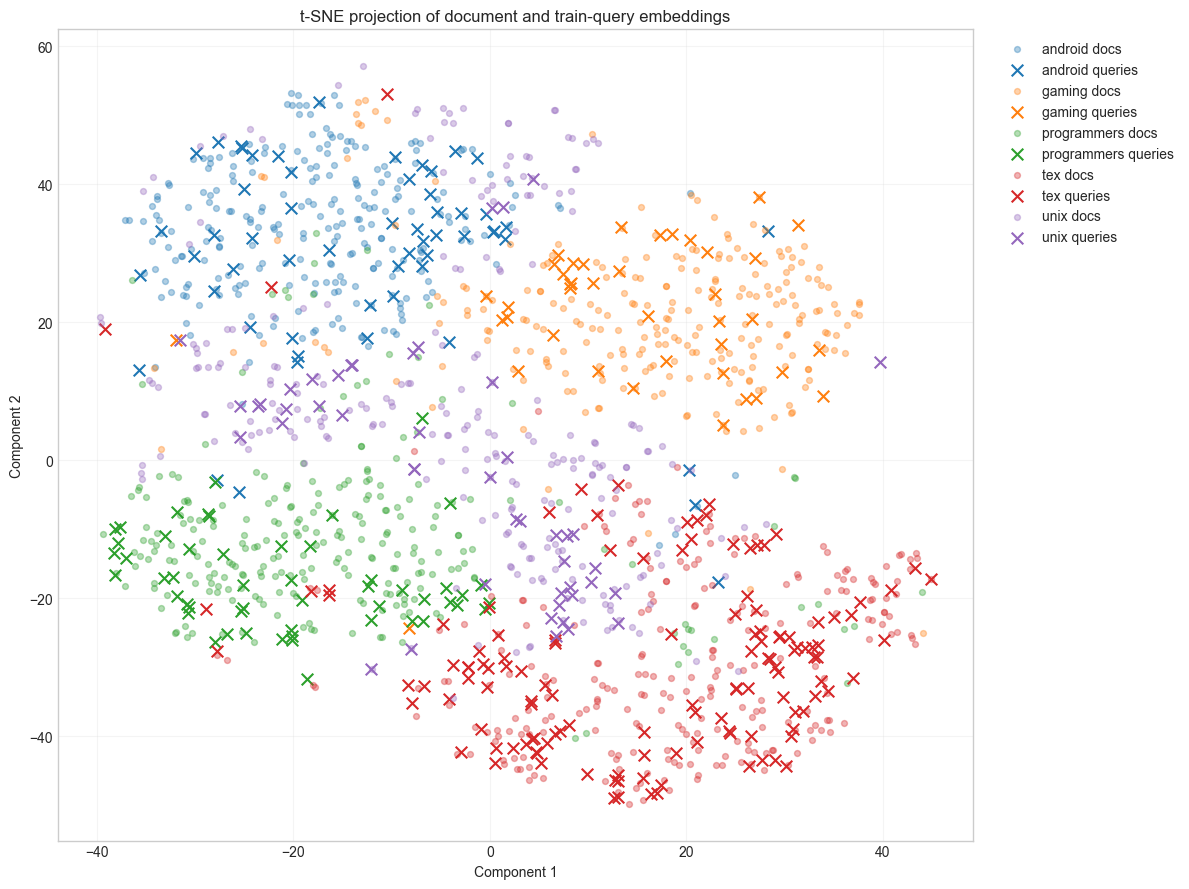

In [8]:
from sklearn.manifold import TSNE

sample_docs_df = (
    frames.docs_raw[['id', 'category']]
    .reset_index()
    .sample(frac=1.0, random_state=42)
    .groupby('category', group_keys=False)
    .head(250)
    .reset_index(drop=True)
)
sample_query_df = frames.train_queries_raw[['id', 'category']].reset_index(drop=False)

doc_sample_embeddings = doc_embeddings[sample_docs_df['index'].to_numpy()]
query_sample_embeddings = train_query_embeddings[sample_query_df['index'].to_numpy()]
combined_embeddings = np.vstack([doc_sample_embeddings, query_sample_embeddings])

plot_df = pd.concat(
    [
        sample_docs_df.assign(source='document')[['id', 'category', 'source']],
        sample_query_df.assign(source='query')[['id', 'category', 'source']],
    ],
    ignore_index=True,
)

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=35)
projection = tsne.fit_transform(combined_embeddings)
plot_df['x'] = projection[:, 0]
plot_df['y'] = projection[:, 1]

fig, ax = plt.subplots(figsize=(12, 9))
color_map = {
    category: plt.colormaps['tab10'](index)
    for index, category in enumerate(sorted(plot_df['category'].unique()))
}
for category, color in color_map.items():
    category_docs = plot_df[(plot_df['category'] == category) & (plot_df['source'] == 'document')]
    category_queries = plot_df[(plot_df['category'] == category) & (plot_df['source'] == 'query')]
    ax.scatter(category_docs['x'], category_docs['y'], s=18, alpha=0.35, color=color, label=f'{category} docs')
    ax.scatter(category_queries['x'], category_queries['y'], s=70, marker='x', linewidths=1.5, color=color, label=f'{category} queries')

ax.set_title('t-SNE projection of document and train-query embeddings')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()

embedding_projection_path = figures_dir / 'embedding_projection.png'
fig.savefig(embedding_projection_path, dpi=220, bbox_inches='tight')
print(f'Saved embedding projection to: {embedding_projection_path}')
print('Observation: categories show partial clustering, but the overlap confirms that semantic themes are shared across sources and that short queries are less separable than full documents.')
plt.show()
